In [0]:
#import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Section 1 - Initial data inspection and loading issues

In [0]:
#read file

td = pd.read_csv("renfe_trains.csv")
td.head()


,company,origin,destination,departure,arrival,vehicle_class,price,fare
0,renfe,MADRID,SEVILLA,2019-05-07 19:00:00,2019-05-07 21:38:00,Preferente,69.4,Promo
1,renfe,MADRID,SEVILLA,2019-05-07 21:25:00,2019-05-08 00:10:00,Turista,43.55,Promo
2,renfe,MADRID,BARCELONA,2019-05-11 08:30:00,2019-05-11 11:15:00,Turista,85.1,Promo
3,renfe,MADRID,BARCELONA,2019-04-18 14:30:00,2019-04-18 17:21:00,Turista,107.7,Flexible
4,renfe,MADRID,BARCELONA,2019-04-28 16:30:00,2019-04-28 19:15:00,Turista,107.7,Flexible


In [0]:
#review types
td.dtypes

company          object
origin           object
destination      object
departure        object
arrival          object
vehicle_class    object
price            object
fare             object
dtype: object

In [0]:
#Insert - review rows where price = price
bad_rows = td[td['price'] == 'price']

bad_rows.head()

,company,origin,destination,departure,arrival,vehicle_class,price,fare
69,company,origin,destination,departure,arrival,vehicle_class,price,fare
146,company,origin,destination,departure,arrival,vehicle_class,price,fare
209,company,origin,destination,departure,arrival,vehicle_class,price,fare
287,company,origin,destination,departure,arrival,vehicle_class,price,fare
347,company,origin,destination,departure,arrival,vehicle_class,price,fare


In [0]:
#Insert - remove price where price = price
td = td[td['price'] != 'price']
bad_rows_removed = td[td['price'] == 'price']
bad_rows_removed.head()


,company,origin,destination,departure,arrival,vehicle_class,price,fare


In [0]:
#Update types
td['price'] = pd.to_numeric(td['price'], errors='coerce')

td['arrival'] = pd.to_datetime(td['arrival'], errors='coerce')
td['departure'] = pd.to_datetime(td['departure'], errors='coerce')

td.dtypes

company                  object
origin                   object
destination              object
departure        datetime64[ns]
arrival          datetime64[ns]
vehicle_class            object
price                   float64
fare                     object
dtype: object

In [0]:
#Review columns - the remaining null fields are resolved later in the case study

td.isnull().sum()

company              0
origin               0
destination          0
departure            0
arrival              0
vehicle_class     8832
price            13179
fare              8832
dtype: int64

# Section 2 - Statistical analysis and observations. 

In [0]:
#Display stats (50% is median)
td.describe()

,price
count,68894.000000
mean,71.493800
std,23.853721
min,16.750000
25%,53.400000
50%,69.400000
75%,85.100000
max,342.800000


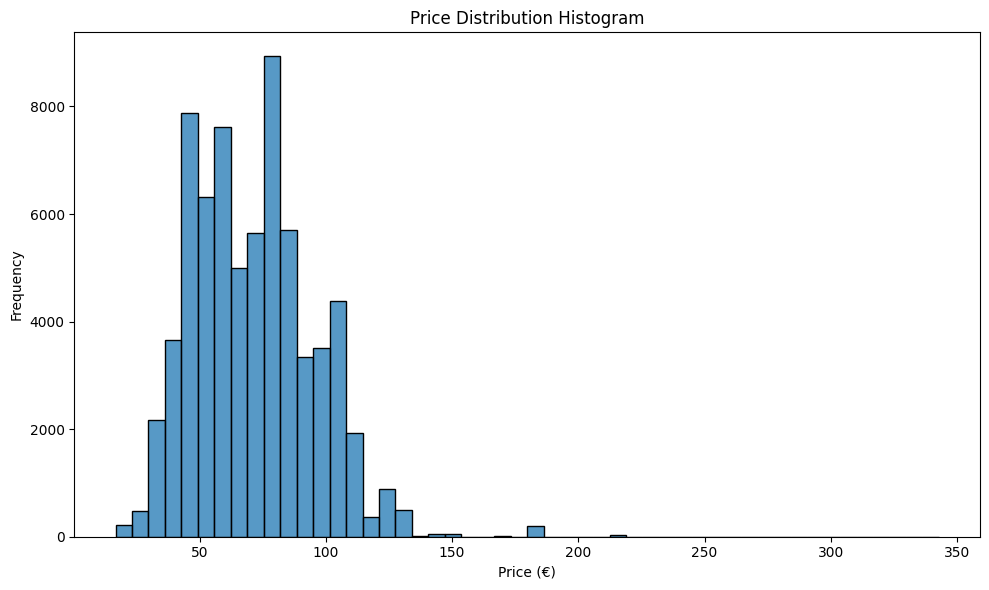

In [0]:
# Histogram Normal

plt.figure(figsize=(10, 6))
sns.histplot(td['price'], bins=50)
plt.title("Price Distribution Histogram")
plt.xlabel("Price (€)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("price_distribution_histogram.png")
plt.show()
plt.close()


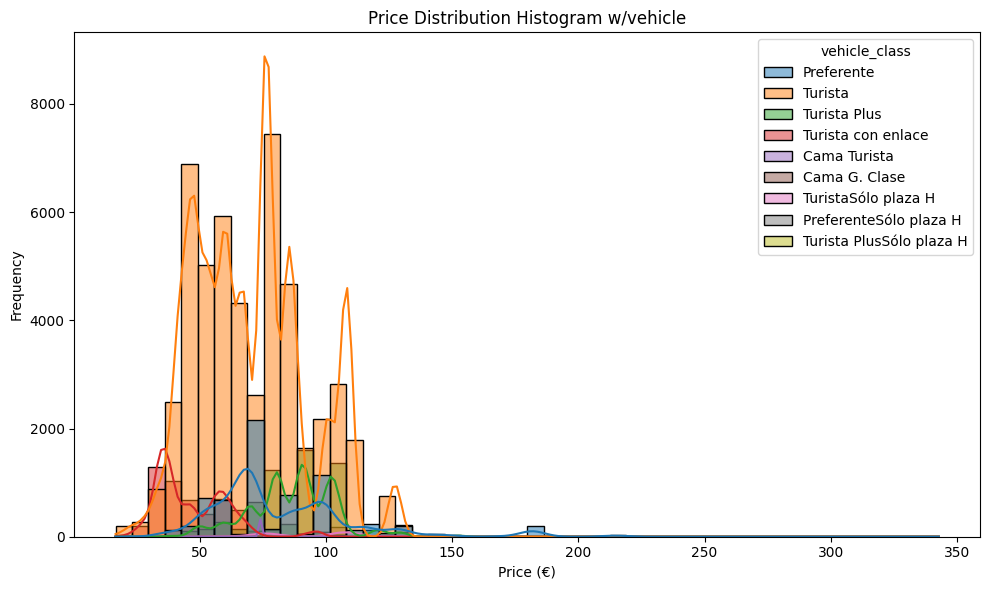

In [0]:
# Histogram vechile split

plt.figure(figsize=(10, 6))
sns.histplot(data=td, x='price', hue='vehicle_class', bins=50, kde=True)
plt.title("Price Distribution Histogram w/vehicle")
plt.xlabel("Price (€)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("price_distribution_histogram_vehiclesplit.png")
plt.show()
plt.close()

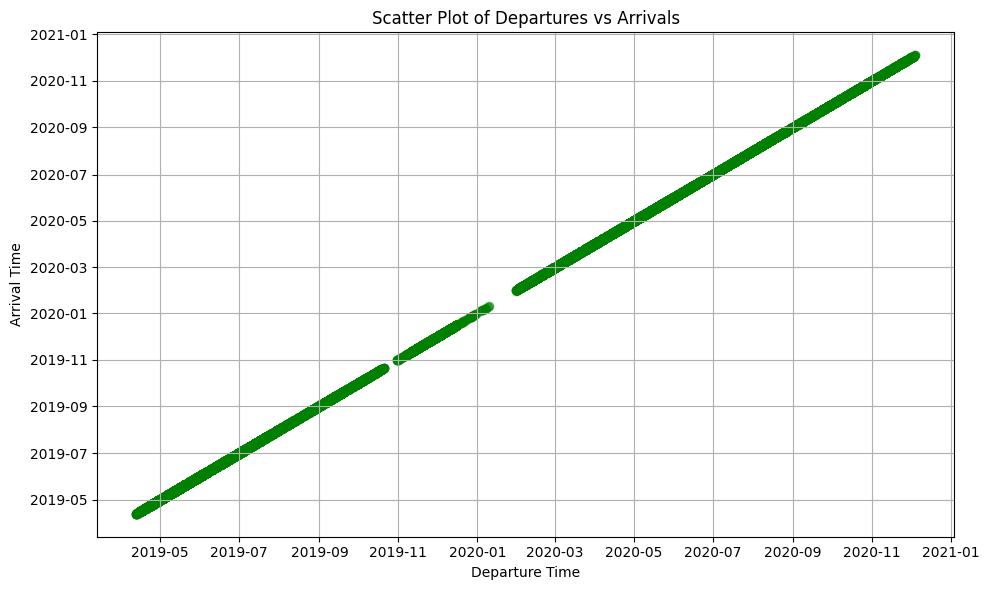

In [0]:

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(td['departure'], td['arrival'], alpha=0.5, color='green')
plt.xlabel('Departure Time')
plt.ylabel('Arrival Time')
plt.title('Scatter Plot of Departures vs Arrivals')
plt.grid(True)
plt.tight_layout()
plt.show()


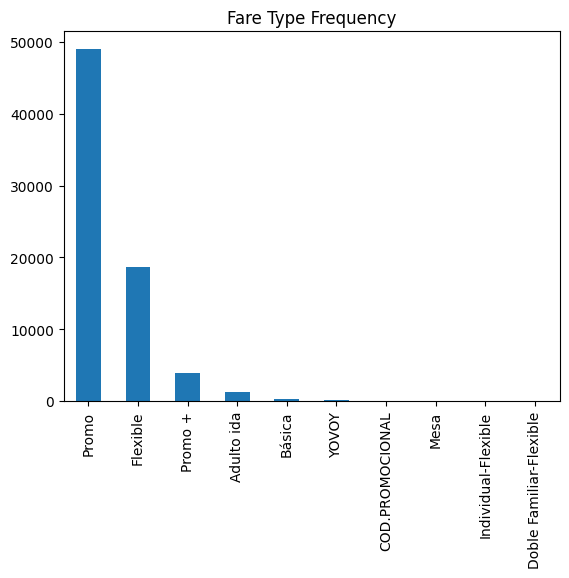

In [0]:
#Frequency of fair 

td['fare'].value_counts().plot(kind='bar')
plt.title("Fare Type Frequency")
plt.show()


# Section 3 - Assess and Manage Missing values

In [0]:
#Check again which columns empty

td.isnull().sum()


company              0
origin               0
destination          0
departure            0
arrival              0
vehicle_class     8832
price            13179
fare              8832
dtype: int64

In [0]:
#Inspect rows with missing (NaN) values

td[td.isnull().any(axis=1)].head()


,company,origin,destination,departure,arrival,vehicle_class,price,fare
11,renfe,MADRID,BARCELONA,2019-05-03 18:30:00,2019-05-03 21:20:00,Preferente,NaN,Promo
15,renfe,MADRID,BARCELONA,2019-04-23 07:30:00,2019-04-23 10:40:00,Turista,NaN,Promo
33,renfe,MADRID,SEVILLA,2019-04-21 21:25:00,2019-04-22 00:10:00,NaN,NaN,NaN
52,renfe,MADRID,SEVILLA,2019-04-17 09:45:00,2019-04-17 12:27:00,Turista,NaN,Flexible
65,renfe,MADRID,SEVILLA,2019-05-03 13:30:00,2019-05-03 16:05:00,Turista,NaN,Promo


In [0]:
#Drop rows with missing vehicle_class, price and fare.  Test 1 (Row check) included 

td = td[~(td[['vehicle_class', 'price', 'fare']].isnull().all(axis=1))]

td[td.isnull().any(axis=1)].head()




,company,origin,destination,departure,arrival,vehicle_class,price,fare
11,renfe,MADRID,BARCELONA,2019-05-03 18:30:00,2019-05-03 21:20:00,Preferente,NaN,Promo
15,renfe,MADRID,BARCELONA,2019-04-23 07:30:00,2019-04-23 10:40:00,Turista,NaN,Promo
52,renfe,MADRID,SEVILLA,2019-04-17 09:45:00,2019-04-17 12:27:00,Turista,NaN,Flexible
65,renfe,MADRID,SEVILLA,2019-05-03 13:30:00,2019-05-03 16:05:00,Turista,NaN,Promo
66,renfe,MADRID,SEVILLA,2019-04-14 09:00:00,2019-04-14 11:38:00,Preferente,NaN,Promo


In [0]:
#Test 2 for removal of columns

td.isnull().sum()


company             0
origin              0
destination         0
departure           0
arrival             0
vehicle_class       0
price            4347
fare                0
dtype: int64

In [0]:
#Add mean as price for remaining rows where ONLY price was empty, with test 1 (column reveiew)

td['price'].fillna(td['price'].mean(), inplace=True)
td[td.isnull().any(axis=1)].head()



,company,origin,destination,departure,arrival,vehicle_class,price,fare


In [0]:
#Test 2 for using mean as the price for remaining rows where ONLY price was empty

td.isnull().sum()

company          0
origin           0
destination      0
departure        0
arrival          0
vehicle_class    0
price            0
fare             0
dtype: int64

# Section 4 - De duplication  

In [0]:
#Check for duplicates

td.duplicated().sum()


43517

In [0]:

top_5_duplicates = td[td.duplicated(keep=False)].head(5)
print(top_5_duplicates)


  company  origin destination  ... vehicle_class   price      fare
0   renfe  MADRID     SEVILLA  ...    Preferente   69.40     Promo
1   renfe  MADRID     SEVILLA  ...       Turista   43.55     Promo
2   renfe  MADRID   BARCELONA  ...       Turista   85.10     Promo
3   renfe  MADRID   BARCELONA  ...       Turista  107.70  Flexible
4   renfe  MADRID   BARCELONA  ...       Turista  107.70  Flexible

[5 rows x 8 columns]


Decided to keep duplicates as it appears to look like normal data (eg. multiple people taking the same train)

# Section 5 - Assess Outliers

In [0]:

# Calculate Q1 and Q3
Q1 = td['price'].quantile(0.25)
Q3 = td['price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = td[(td['price'] < lower_bound) | (td['price'] > upper_bound)]

# View outliers
print(outliers)


      company  origin destination  ... vehicle_class   price      fare
228     renfe  MADRID   BARCELONA  ...    Preferente  181.50  Flexible
2038    renfe  MADRID   BARCELONA  ...    Preferente  181.50  Flexible
2089    renfe  MADRID   BARCELONA  ...    Preferente  149.95     Promo
2094    renfe  MADRID   BARCELONA  ...    Preferente  214.20  Flexible
2370    renfe  MADRID   BARCELONA  ...    Preferente  181.50  Flexible
...       ...     ...         ...  ...           ...     ...       ...
68022   renfe  MADRID   BARCELONA  ...    Preferente  183.50  Flexible
68092   renfe  MADRID   BARCELONA  ...    Preferente  151.55     Promo
68449   renfe  MADRID   BARCELONA  ...    Preferente  144.95     Promo
70340   renfe  MADRID   BARCELONA  ...    Preferente  183.50  Flexible
71553   renfe  MADRID   BARCELONA  ...    Preferente  183.50  Flexible

[376 rows x 8 columns]


In [0]:
#Review lower bound and upper bound for context

print('Lower bound:',lower_bound)
print('Upper bound:',upper_bound)


Lower bound: 5.850000000000001
Upper bound: 132.64999999999998


Keep outliers

# Section 6 - Stretch exercises